NAME: SHABAB ZAHRA

CMS ID: 023-24-0088

SECTION D

GITHUB:https://github.com/shababzahraa/ML-Tasks

In [ ]:
import pandas as pd
df = pd.read_csv("Clean_churn.csv")
print("Shape:", df.shape)
print("Data types of columns:\n", df.dtypes)

print("Missing Values:\n", df.isnull().sum())

Shape: (7043, 20)
Data types of columns:
 gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
Missing Values:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod  

2.	In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business? 
 
The goal is to predict whether a telecom customer will churn (leave the company) or not. This is important for the business because identifying customers who may leave can help the company take actions to retain them.


In [ ]:
#3.	Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any identifier column still present. 
y = df['Churn'].map({'Yes' : 1, 'No': 0})
print(y)
X = df.drop(columns=['Churn'])
print("Y:", y.head())
print("X:\n", X.head)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64
Y: 0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64
X:
 <bound method NDFrame.head of       gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes       

Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping). 
I used one-hot encoding because the dataset contains several categorical columns with multiple categories. One-hot encoding converts these categories into numeric 0/1 columns without assuming that one category is greater or smaller than another.

In [ ]:
#4.	Convert every remaining categorical column in X into numeric form.
x = pd.get_dummies(X, drop_first=True)
print(x.head())


   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False  ...   
3               

In [ ]:
#5.	Confirm X contains only numeric columns and has no missing values before moving on. 
print("Confirm x has only numeric columns and no missing values:\n")
print(x.dtypes)
print(x.isnull().sum())

Confirm x has only numeric columns and no missing values:

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSuppor

In [ ]:
#6.	Split X and y into training and test sets (e.g. an 80/20 split). 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


Why is stratify=y a sensible choice, given what you found about the target's class balance in Lab 2? 

stratify=y is a sensible choice because the Churn classes are not perfectly balanced. It keeps a similar proportion of churned and non-churned customers in both the training and test sets, making the evaluation more reliable.

In [ ]:
#7.	Report the shape of X_train, X_test, y_train, and y_test. 
print("Shape of x_train: ", x_train.shape)
print("Shape of x_test: ", x_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)

Shape of x_train:  (5634, 30)
Shape of x_test:  (1409, 30)
Shape of y_train:  (5634,)
Shape of y_test:  (1409,)


In [ ]:
#8.	Train a DecisionTreeClassifier on the training data with default settings (only random_state fixed).#
#  Generate predictions on both the training and test sets. 
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)
y_train_prediction = dt_model.predict(x_train)
y_test_prediction = dt_model.predict(x_test)
print("Prediction on Training data:\n", y_train_prediction)
print("Prediction on Test data:\n", y_test_prediction)

Prediction on Training data:
 [0 0 0 ... 1 0 0]
Prediction on Test data:
 [0 1 0 ... 0 0 0]


In [ ]:
#9.	What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?
print("Depth of tree:", dt_model.get_depth())

Depth of tree: 24


In [ ]:
#10.	Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table. 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_test_prediction)
precision = precision_score(y_test, y_test_prediction)
recall = recall_score(y_test, y_test_prediction)
f1 = f1_score(y_test, y_test_prediction)
print("Accuracy: ", round(accuracy, 4))
print("\nprecision: ", round(precision,4))
print("\nRecall: ", round(recall,4))
print("\nF1 Score: ", round(f1,4))

Accuracy:  0.7417

precision:  0.5139

Recall:  0.4947

F1 Score:  0.5041


| Metric | Test Set Result |
|---:|---:|
| Accuracy | 0.7417 |
| Precision | 0.5139 |
| Recall | 0.4947 |
| F1 Score | 0.5041 |


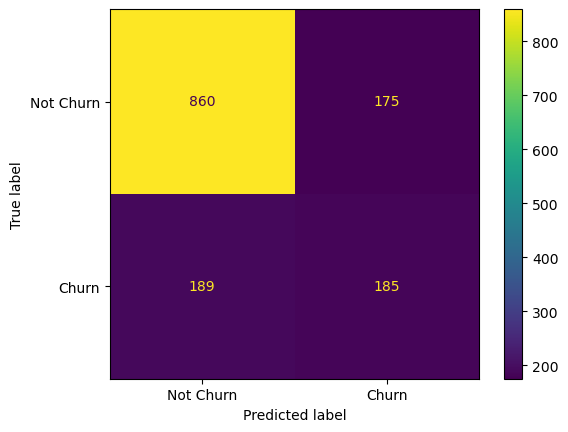

In [ ]:
#11.	Plot the confusion matrix for the test set. 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion = confusion_matrix(y_test, y_test_prediction)
ConfusionMatrixDisplay(confusion, display_labels=['Not Churn', 'Churn']).plot()

How many actual churners did the model correctly catch, and how many did it miss? 
The confusion matrix shows that 185 customers who actually churned were correctly identified by the model, while 189 actual churners were incorrectly predicted as non-churners.

12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

Because the classes are imbalanced, I trust recall, precision, and F1-score more than accuracy. Recall is especially important because it tells us how many actual churners the model correctly identifies. Missing a churner means the company may lose a customer, so we want to catch as many actual churners as possible. F1-score is also useful because it balances precision and recall.

In [ ]:
#13. Compare your baseline tree's accuracy on the training set vs. the test set.
from sklearn.metrics import accuracy_score
train_accuracy = accuracy_score(y_train, y_train_prediction)
test_accuracy = accuracy_score(y_test, y_test_prediction)
print("Training Accuracy: ", round(train_accuracy,4))
print("Test Accuracy: ", round(test_accuracy,4))

Training Accuracy:  0.998
Test Accuracy:  0.7417


Is there a large gap? What does that suggest about the model? 

The baseline tree achieved 99.8% accuracy on the training set but only 74.17% on the test set. The large gap of 25.63 percentage points suggests that the model is overfitting and does not generalize well to unseen data.

In [ ]:
#14. Train several Decision Trees at different max_depth values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted).
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
depths = [2,3,4,5,6,7,8,9,10,None]
accuracies = []
for depth in depths:
    model=DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(x_train, y_train)
    train_prediction = model.predict(x_train)
    test_prediction = model.predict(x_test)

    train_acc = accuracy_score(y_train, train_prediction)
    test_acc = accuracy_score(y_test, test_prediction)

    accuracies.append([depth, train_acc, test_acc])

df = pd.DataFrame(accuracies, columns=["Max Depth", "Train Accuracy", "Test Accuracy"])
df

,Max Depth,Train Accuracy,Test Accuracy
0,2.0,0.791090,0.787083
1,3.0,0.791090,0.787083
2,4.0,0.792510,0.795600
3,5.0,0.801207,0.794180
4,6.0,0.807064,0.797019
5,7.0,0.822151,0.790632
6,8.0,0.834931,0.779986
7,9.0,0.853035,0.773598
8,10.0,0.872204,0.755855
9,NaN,0.998048,0.741661


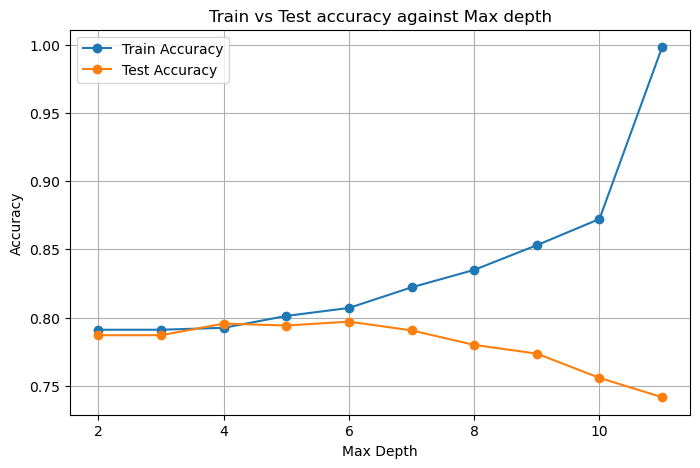

In [ ]:
#. 15. Plot train accuracy and test accuracy against max_depth on the same chart. At roughly what depth does the 
#model start to overfit? Explain how the chart shows this. 
import matplotlib.pyplot as plt
depths = [2,3,4,5,6,7,8,9,10,11]
train_acc = []
test_acc = []
for x in accuracies:
    train_acc.append(x[1])
    test_acc.append(x[2])

plt.figure(figsize = (8,5))
plt.plot(depths, train_acc, marker='o', label="Train Accuracy")
plt.plot(depths, test_acc, marker='o', label="Test Accuracy")
plt.title("Train vs Test accuracy against Max depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

The model starts to overfit at roughly depth 7. The chart shows that after depth 6, training accuracy continues to increase while test accuracy starts to decrease. This indicates that the model is learning the training data too closely and is not generalizing well to unseen data.

16. Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3 
sentences — it should not simply be the depth with the highest training accuracy. 

I selected max_depth = 6 as the best model because it gives the highest test accuracy of 79.70% while maintaining a similar training accuracy of 80.71%. The small difference between training and test accuracy suggests that the model generalizes well and is less overfitted than deeper trees.

In [ ]:
#Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Part 5) for comparison against the baseline. 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
best_model = DecisionTreeClassifier(max_depth=6, random_state=42)
best_model.fit(x_train, y_train)

y_test_pred = best_model.predict(x_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

Accuracy: 0.797
Precision: 0.6746
Recall: 0.4545
F1-score: 0.5431


In [ ]:
#18. Retrain a Decision Tree with “entropy” as the splitting criterion rather than the default (“gini”) and 
# report its full evaluation metrics (as in Part 5) for comparison against the baseline. 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(x_train, y_train)
y_prediction = model.predict(x_test)

accuracy = accuracy_score(y_test, y_prediction)
precision = precision_score(y_test, y_prediction)
recall = recall_score(y_test, y_prediction)
f1 = f1_score(y_test, y_prediction)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

Accuracy: 0.7303
Precision: 0.4921
Recall: 0.5027
F1-score: 0.4974


The entropy-based Decision Tree achieved an accuracy of 73.03%, precision of 49.21%, recall of 50.27%, and F1-score of 49.74%. Compared with the baseline Gini tree, the entropy model performed slightly worse overall, although its recall was slightly higher.

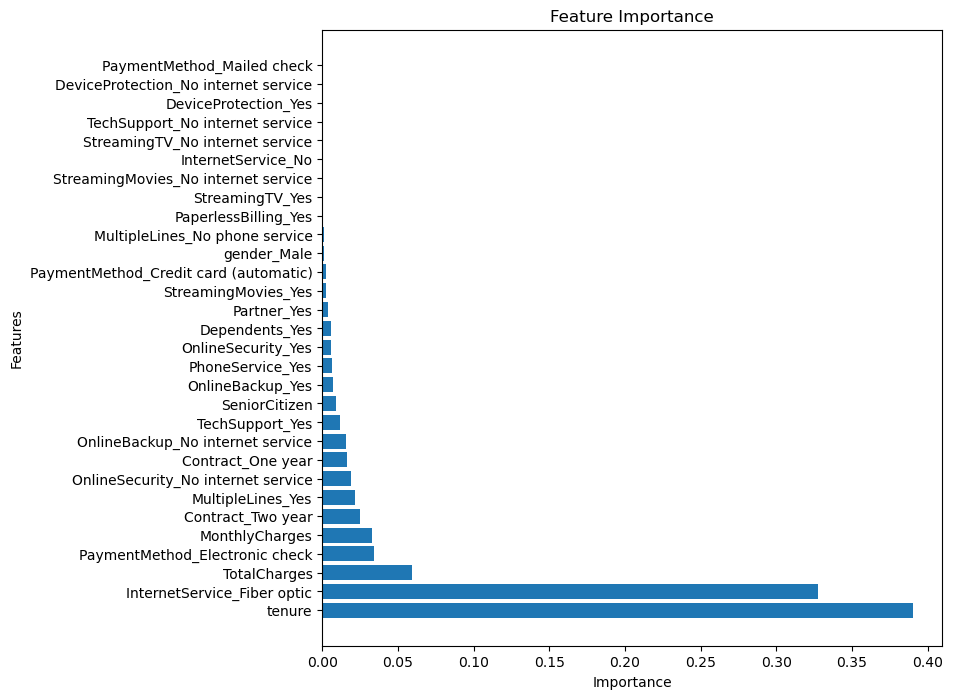

In [ ]:
#19. Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most? 
importances = best_model.feature_importances_
feature_importance = pd.Series(importances, index=x_train.columns).sort_values(ascending=False)
feature_importance

import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.barh(feature_importance.index, feature_importance.values)
plt.title("Feature Importance")
plt.ylabel("Features")
plt.xlabel("Importance")
plt.show()

The top five important features are tenure, InternetService_Fiber optic, TotalCharges, PaymentMethod_Electronic check, and MonthlyCharges. Among these, tenure and Fiber optic Internet Service have the highest importance in predicting customer churn.

20. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the 
patterns you saw then? 

Yes, the feature importance results agree with the patterns found in Lab 2 EDA. Tenure, InternetService, and MonthlyCharges were analyzed against churn in Lab 2 and showed noticeable differences between churned and non-churned customers. These features also appear among the most important features in the Decision Tree.

21. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are 
its main limitations? 

I selected the Decision Tree model with a maximum depth of 6 as the final model. It achieved a test accuracy of 79.70%, with a precision of 67.46%, recall of 45.45%, and F1-score of 54.31%. It performed better than the baseline model and showed less overfitting. The main limitation is that its recall is relatively low, meaning it misses some customers who actually churn. Another limitation is that Decision Trees can be sensitive to the data and may overfit if the tree becomes too deep.

22. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling 
class imbalance)? Describe it — do not implement it here. 

If I had more time, I would try a different algorithm such as Random Forest or Logistic Regression to compare its performance with the Decision Tree. I would also do more feature engineering, such as creating useful customer groups from tenure and monthly charges. Since the Churn classes are imbalanced, I would try class balancing techniques such as class weights or oversampling. These steps could improve the model’s ability to identify actual churned customers and increase recall.

In [ ]:
#23. Implement ID3 from scratch on the Play Badminton dataset from class. No built-in decision tree libraries — 
# write your own entropy and information gain functions. Print the gain values for each attribute at every split.  
import pandas as pd 
import math
df = pd.read_csv("Clean_churn.csv")
def entropy(data):
    count = data["Churn"].value_counts()
    p = count.get("No", 0)
    n = count.get("Yes", 0)
    total = p + n
    if total == 0:
        return 0
    p_prob = p/total
    n_prob = n/total
    total_entropy = 0

    if p_prob > 0:
        total_entropy -= p_prob * math.log2(p_prob)

    if n_prob > 0:
        total_entropy -= n_prob * math.log2(n_prob)

    return total_entropy

def information_gain(data, attribute):
    overall_entropy = entropy(data)

    weighted_entropy = 0
    for value in data[attribute].unique():
        subset =  data[data[attribute] == value]
        subset_entropy = entropy(subset)
        
        weight = len(subset) / len(data)
        weighted_entropy += (weight * subset_entropy) 

    gain = overall_entropy - weighted_entropy
    return gain

attributes = df.columns.drop(["Churn", "tenure", "MonthlyCharges", "TotalCharges"])
print("----Feature : Gain------------")
best_gain = 0
best_attribute = None
for attribute in attributes:
    gain = information_gain(df, attribute)
    if(gain > best_gain):
        best_gain = gain
        best_attribute = attribute

print("\n-----------------------------------------------------\n")
print("Best Attribute = ", best_attribute, "\nGain = ", best_gain)

print("\n-----------------------------------------------------\n")
for value in df[best_attribute].unique():
    subset = df[df[best_attribute] == value]

    print("\nBranch:", value)
    remaining_attributes = attributes.drop(best_attribute)
    branch_best_gain = 0
    branch_best_attribute = None
    for attribute in remaining_attributes:
        gain = information_gain(subset, attribute)
        if gain > branch_best_gain:
            branch_best_gain = gain
            branch_best_attribute = attribute
    print("Best Attribute:", branch_best_attribute)
    print("Gain:",branch_best_gain)

def id3(data, attributes):

    if len(data["Churn"].unique()) == 1:
        return data["Churn"].iloc[0]

    if len(attributes) == 0:
        return data["Churn"].mode()[0]

    best_gain = 0
    best_attribute = None

    for attribute in attributes:
        gain = information_gain(data, attribute)

        if gain > best_gain:
            best_gain = gain
            best_attribute = attribute

    if best_attribute is None:
        return data["Churn"].mode()[0]

    print("Split:", best_attribute, "| Gain:", best_gain)

    tree = {best_attribute: {}}

    remaining_attributes = attributes.drop(best_attribute)

    for value in data[best_attribute].unique():

        subset = data[data[best_attribute] == value]

        tree[best_attribute][value] = id3(
            subset,
            remaining_attributes
        )

    return tree


tree = id3(df, attributes)

print("\nID3 Tree:")
print(tree)


----Feature : Gain------------

-----------------------------------------------------

Best Attribute =  Contract 
Gain =  0.14203773193805125

-----------------------------------------------------


Branch: Month-to-month
Best Attribute: InternetService
Gain: 0.058089274230351595

Branch: One year
Best Attribute: StreamingMovies
Gain: 0.04313440871266638

Branch: Two year
Best Attribute: InternetService
Gain: 0.015739958212791783
Split: Contract | Gain: 0.14203773193805125
Split: InternetService | Gain: 0.058089274230351595
Split: PaymentMethod | Gain: 0.019013366066821913
Split: OnlineBackup | Gain: 0.033189444828361836
Split: MultipleLines | Gain: 0.03829585951072778
Split: TechSupport | Gain: 0.12896711207764977
Split: gender | Gain: 0.07819452107210567
Split: Dependents | Gain: 0.1277217544981898
Split: DeviceProtection | Gain: 0.06608000916542367
Split: SeniorCitizen | Gain: 0.0724444222363898
Split: PaperlessBilling | Gain: 0.17522874204791372
Split: Partner | Gain: 0.1546249654